# Batch correction for Visium and scRNA-seq data

When you combine multiple samples such as different capture areas, different donors, different sequencing runs, or different technologies, the resulting clusters often separate by *sample* instead of by *biology*. This is a **batch effect**: a technical source of variation that is entangled with the signal you actually care about. Before you can jointly cluster, annotate, or compare samples, you usually need to correct for it.

This notebook walks through **visualizing the batch effect → correcting it → re-visualizing → checking** in two different contexts:

- **Part A:** batch correction across **five scRNA-seq datasets** (dissociated single cells, different studies/technologies)
- **Part B:** batch correction across **two Visium sections** (spot-based spatial data, same tissue block but different capture areas)

How to use this Google Colab

- Select Python as the programming language: Click "Runtime -> Change runtime type", then ensure "Runtime type" is set to "Python". There could be resource usage [limitations](https://research.google.com/colaboratory/faq.html#usage-limits).
- Click the "Connect" button on the top-right corner. Now, you are ready to run the tutorial.
- The notebook uses public datasets by default. Each data-loading section also explains how to swap in your own data.

# **1. Install and import packages**

We use the `scanpy`/`squidpy` (scverse) ecosystem plus two batch-correction packages: [`harmonypy`](https://github.com/slowkow/harmonypy) (a fast, PCA-space correction method) and [`scanorama`](https://github.com/brianhie/scanorama) (a panel-matching method based on mutual nearest neighbors). We will apply both to each dataset so we can compare them side by side.

In [1]:
# Install required python packages (takes ~1-2 min)
# '!' is used when using bash command instead of python in this Colab notebook
!uv pip install scanpy==1.11.2 squidpy==1.6.5 harmonypy==0.0.10 scanorama==1.7.4 igraph==0.11.8 leidenalg==0.10.2

# import the python packages
import scanpy as sc
import squidpy as sq
import anndata as ad
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scanorama
import warnings
import gc

warnings.filterwarnings("ignore")
sc.settings.verbosity = 1

Using Python 3.13.15 environment at: /usr
Resolved 122 packages in 4.40s
Prepared 44 packages in 14.08s
Uninstalled 2 packages in 26ms
Installed 44 packages in 129ms
 + aiobotocore==2.26.0
 + aioitertools==0.13.0
 + anndata==0.12.19
 + annoy==1.17.3
 + array-api-compat==1.15.0
 + asciitree==0.3.3
 + botocore==1.41.5
 - dask==2026.8.0
 + dask==2024.11.2
 + dask-image==2026.5.0
 + datashader==0.19.1
 + deprecated==3.0.0
 + docrep==0.3.2
 + fasteners==0.20
 + fbpca==1.0
 + geosketch==1.3
 + harmonypy==0.0.10
 + igraph==0.11.8
 + intervaltree==3.2.1
 + jmespath==1.1.0
 + legacy-api-wrap==1.5
 + leidenalg==0.10.2
 + matplotlib-scalebar==0.9.0
 + multiscale-spatial-image==2.0.3
 + numcodecs==0.15.1
 + ome-zarr==0.11.1
 + omnipath==1.0.12
 + pims==0.7
 + pyct==0.6.0
 + s3fs==2025.12.0
 + scanorama==1.7.4
 + scanpy==1.11.2
 + scverse-misc==0.1.6
 + session-info2==0.4.2
 + slicerator==1.1.0
 + spatial-image==1.2.3
 + spatialdata==0.5.0
 + squidpy==1.6.5
 + texttable==1.7.0
 + validators==0.35.0

/usr/local/lib/python3.13/dist-packages/scanpy/_utils/__init__.py:33: FutureWarning: `__version__` is deprecated, use `importlib.metadata.version('anndata')` instead.
  from anndata import __version__ as anndata_version
/usr/local/lib/python3.13/dist-packages/scanpy/__init__.py:24: FutureWarning: `__version__` is deprecated, use `importlib.metadata.version('anndata')` instead.
  if Version(anndata.__version__) >= Version("0.11.0rc2"):
/usr/local/lib/python3.13/dist-packages/scanpy/readwrite.py:16: FutureWarning: `__version__` is deprecated, use `importlib.metadata.version('anndata')` instead.
  if Version(anndata.__version__) >= Version("0.11.0rc2"):
/usr/local/lib/python3.13/dist-packages/leidenalg/VertexPartition.py:413: SyntaxWarning: invalid escape sequence '\m'
  .. math:: Q = \\frac{1}{m} \\sum_{ij} \\left(A_{ij} - \\frac{k_i^\mathrm{out} k_j^\mathrm{in}}{m} \\right)\\delta(\\sigma_i, \\sigma_j),
/usr/local/lib/python3.13/dist-packages/leidenalg/VertexPartition.py:788: SyntaxWarn

# **2. Part A: Batch correction for scRNA-seq data**

## 2.1 Load a multi-batch scRNA-seq dataset

We use the human **pancreas** dataset that has become a standard benchmark for scRNA-seq batch correction (used in the original Harmony and Scanorama papers). It combines ~14,700 cells from **5 independent studies**, several using different sequencing technologies (inDrop, CEL-Seq2, SMART-Seq2, Fluidigm C1), and comes with annotated cell type labels so we can check that correction removes the *study* signal while preserving the *cell type* signal.

In [ ]:
# Download the pancreas multi-batch benchmark dataset (~200 MB, takes ~1 min)
!wget -nc https://ndownloader.figshare.com/files/24539828 -O pancreas.h5ad

In [ ]:
# Load the dataset
adata_sc = sc.read_h5ad("pancreas.h5ad")

# This file's batch/technology column is called "tech" (not "batch"); alias it so the
# rest of this notebook can use a consistent "batch" key for every integration method
adata_sc.obs["batch"] = adata_sc.obs["tech"].astype("category")

# Take a look at the AnnData object
adata_sc

**Using your own data:** replace the two cells above with a load of your own per-sample files (e.g. `sc.read_10x_mtx()` or `sc.read_h5ad()` for each sample), then combine them with:

```python
adata_sc = ad.concat(
    {"sample1": adata1, "sample2": adata2, "sample3": adata3},
    label="batch",
    index_unique="-",
)
```

Keep the resulting batch column name (`"batch"` here) consistent — it is what we pass to Harmony and Scanorama below.

## 2.2 Standard preprocessing

As with any scRNA-seq dataset, we start with the usual QC and normalization steps before looking for batch effects.

In [ ]:
# Basic QC filtering
sc.pp.filter_cells(adata_sc, min_genes=200)
sc.pp.filter_genes(adata_sc, min_cells=3)

adata_sc

In [ ]:
# This dataset ships already log-normalized (adata_sc.X is log1p-normalized counts;
# raw counts live in adata_sc.layers["counts"] and size factors in adata_sc.obs["size_factors"]),
# so we do NOT call normalize_total/log1p again here - just record it as "lognorm" for downstream steps.
# if normalization is needed refer back to the pre-processing tutorial
adata_sc.layers["lognorm"] = adata_sc.X.copy()

# Find highly variable genes and restrict to them for the batch-correction steps
sc.pp.highly_variable_genes(adata_sc, n_top_genes=2000, batch_key="batch")
adata_sc = adata_sc[:, adata_sc.var.highly_variable].copy()

# Scale and run PCA
sc.pp.scale(adata_sc, max_value=10)
sc.tl.pca(adata_sc, n_comps=30)

## 2.3 Visualize the batch effect (before correction)

We compute a neighbor graph and UMAP directly on the uncorrected PCA space, then color by `batch` (technical) and by `cell_type` (biological) side by side. If there is a strong batch effect, cells will cluster more by study than by cell type.

In [ ]:
sc.pp.neighbors(adata_sc, use_rep="X_pca")
sc.tl.umap(adata_sc)
adata_sc.obsm["X_umap_uncorrected"] = adata_sc.obsm["X_umap"].copy()

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
sc.pl.embedding(adata_sc, basis="X_umap_uncorrected", color="batch", ax=axes[0], show=False, title="Uncorrected: colored by batch")
sc.pl.embedding(adata_sc, basis="X_umap_uncorrected", color="celltype", ax=axes[1], show=False, title="Uncorrected: colored by cell type")
plt.tight_layout()

## 2.4 Batch correction with Harmony

[Harmony](https://www.nature.com/articles/s41592-019-0619-0) iteratively adjusts the PCA embedding so that cells from different batches that are otherwise similar get pulled together, while trying to preserve genuine biological clusters. It operates directly on `X_pca` and is fast even for large datasets.

In [ ]:
# Run Harmony on the existing PCA embedding (adds adata_sc.obsm["X_pca_harmony"])
sc.external.pp.harmony_integrate(adata_sc, key="batch")

# Recompute neighbors/UMAP on the Harmony-corrected embedding
sc.pp.neighbors(adata_sc, use_rep="X_pca_harmony")
sc.tl.umap(adata_sc)
adata_sc.obsm["X_umap_harmony"] = adata_sc.obsm["X_umap"].copy()

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
sc.pl.embedding(adata_sc, basis="X_umap_harmony", color="batch", ax=axes[0], show=False, title="Harmony: colored by batch")
sc.pl.embedding(adata_sc, basis="X_umap_harmony", color="celltype", ax=axes[1], show=False, title="Harmony: colored by cell type")
plt.tight_layout()

## 2.5 Batch correction with Scanorama

[Scanorama](https://www.nature.com/articles/s41587-019-0113-3) finds mutual nearest neighbors between pairs of batches and uses them to compute a batch-corrected low-dimensional embedding, without assuming all batches share every cell type. It scales well to many batches with only partial overlap in composition.

In [ ]:
# Scanorama needs the batches as a list of AnnData objects with a shared var (gene) set
batch_cats = adata_sc.obs["batch"].cat.categories
adata_list = [adata_sc[adata_sc.obs["batch"] == b].copy() for b in batch_cats]

scanorama.integrate_scanpy(adata_list, dimred=30)

# Stitch the per-batch Scanorama embeddings back into one array in the original cell order
adata_sc.obsm["X_scanorama"] = np.zeros((adata_sc.n_obs, 30))
for b, ad_b in zip(batch_cats, adata_list):
    adata_sc.obsm["X_scanorama"][adata_sc.obs["batch"] == b] = ad_b.obsm["X_scanorama"]

# Recompute neighbors/UMAP on the Scanorama-corrected embedding
sc.pp.neighbors(adata_sc, use_rep="X_scanorama")
sc.tl.umap(adata_sc)
adata_sc.obsm["X_umap_scanorama"] = adata_sc.obsm["X_umap"].copy()

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
sc.pl.embedding(adata_sc, basis="X_umap_scanorama", color="batch", ax=axes[0], show=False, title="Scanorama: colored by batch")
sc.pl.embedding(adata_sc, basis="X_umap_scanorama", color="celltype", ax=axes[1], show=False, title="Scanorama: colored by cell type")
plt.tight_layout()

## 2.6 Compare Harmony vs. Scanorama

We now put all three embeddings (uncorrected, Harmony, Scanorama) side by side, colored by batch. A good correction mixes the batch colors within each cluster while keeping the cell-type panel below cleanly separated.

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, basis, title in zip(
    axes,
    ["X_umap_uncorrected", "X_umap_harmony", "X_umap_scanorama"],
    ["Uncorrected", "Harmony", "Scanorama"],
):
    sc.pl.embedding(adata_sc, basis=basis, color="batch", ax=ax, show=False, title=title)
plt.tight_layout()

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, basis, title in zip(
    axes,
    ["X_umap_uncorrected", "X_umap_harmony", "X_umap_scanorama"],
    ["Uncorrected", "Harmony", "Scanorama"],
):
    sc.pl.embedding(adata_sc, basis=basis, color="celltype", ax=ax, show=False, title=title)
plt.tight_layout()

In [ ]:
# A simple quantitative check: cluster each embedding, then look at how evenly
# each cluster is composed of the different batches. A well-mixed cluster should contain
# cells from most/all batches roughly in proportion to their overall abundance.
sc.pp.neighbors(adata_sc, use_rep="X_pca_harmony")
sc.tl.leiden(adata_sc, key_added="leiden_harmony", flavor="igraph", n_iterations=-1, resolution=0.5)

crosstab = pd.crosstab(adata_sc.obs["leiden_harmony"], adata_sc.obs["batch"], normalize="index")
crosstab.round(2)

In [ ]:
# Free memory before moving on to the Visium section, only necessary in colab
del adata_list
del adata_sc
gc.collect()

# **3. Part B: Batch correction for Visium data**

## 3.1 Load two Visium sections

We use two serial sections from the same public 10x Genomics **human breast cancer** block (`V1_Breast_Cancer_Block_A_Section_1` and `_Section_2`). Because these are different capture areas processed on different slides, they still show a real batch effect even though the underlying tissue block is the same — a useful, relatively "easy" case to build intuition before tackling batches from different patients or platforms.

In [2]:
# Download both Visium sections (~1-2 min combined)
adata_v1 = sq.datasets.visium("V1_Breast_Cancer_Block_A_Section_1")
adata_v2 = sq.datasets.visium("V1_Breast_Cancer_Block_A_Section_2")

adata_v1.var_names_make_unique()
adata_v2.var_names_make_unique()

  0%|          | 0.00/9.50M [00:00<?, ?B/s]

  0%|          | 0.00/26.9M [00:00<?, ?B/s]

  0%|          | 0.00/9.87M [00:00<?, ?B/s]

  0%|          | 0.00/27.6M [00:00<?, ?B/s]

In [3]:
# Combine the two sections into one AnnData, keeping a "batch" column and each
# section's own spatial coordinates/image under its own library_id
adata_vis = ad.concat(
    {"section_1": adata_v1, "section_2": adata_v2},
    label="batch",
    uns_merge="unique",
    index_unique="-",
)
adata_vis.obs["batch"] = adata_vis.obs["batch"].astype("category")

# ad.concat keeps each section's original library_id key in .uns["spatial"]
# (Ex. "V1_Breast_Cancer_Block_A_Section_1"); rebuild it keyed by our own
# "section_1"/"section_2" labels so sc.pl.spatial(..., library_id=...) below can find them
adata_vis.uns["spatial"] = {
    "section_1": adata_v1.uns["spatial"][next(iter(adata_v1.uns["spatial"]))],
    "section_2": adata_v2.uns["spatial"][next(iter(adata_v2.uns["spatial"]))],
}

adata_vis

AnnData object with n_obs × n_vars = 7785 × 36601
    obs: 'in_tissue', 'array_row', 'array_col', 'batch'
    uns: 'spatial'
    obsm: 'spatial'

**Using your own data:** replace the two cells above with `sc.read_visium("path/to/spaceranger_outs/")` (or `spatialdata_io.visium()` if you want a full `SpatialData` object) for each of your Visium samples, then combine them the same way with `ad.concat(..., label="batch")`.

## 3.2 Standard preprocessing

Spots aggregate many cells each, so count thresholds for Visium are usually higher than for single-cell or single-molecule (Xenium) data. We plot the count distribution first to choose a sensible cutoff.

Text(0, 0.5, 'Number of spots')

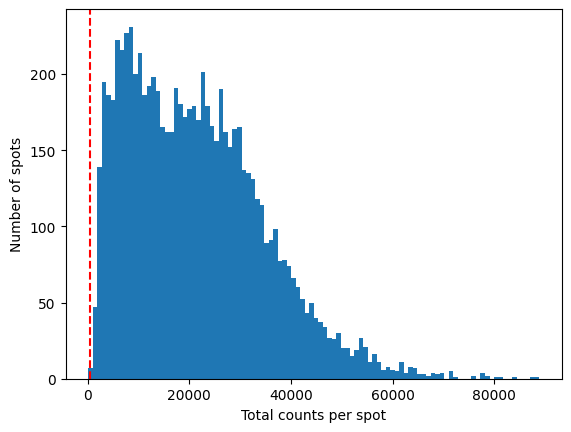

In [4]:
sc.pp.calculate_qc_metrics(adata_vis, inplace=True, percent_top=None)

fig = plt.hist(adata_vis.obs["total_counts"], bins=100)
plt.axvline(x=500, color="r", linestyle="--")
plt.xlabel("Total counts per spot")
plt.ylabel("Number of spots")

In [5]:
# Filter low-count spots and rarely-detected genes
sc.pp.filter_cells(adata_vis, min_counts=500)
sc.pp.filter_genes(adata_vis, min_cells=10)

# Normalize, log-transform, find HVGs, scale, and run PCA
sc.pp.normalize_total(adata_vis, target_sum=1e4)
sc.pp.log1p(adata_vis)
sc.pp.highly_variable_genes(adata_vis, n_top_genes=2000, batch_key="batch")
adata_vis = adata_vis[:, adata_vis.var.highly_variable].copy()
sc.pp.scale(adata_vis, max_value=10)
sc.tl.pca(adata_vis, n_comps=30)

## 3.3 Visualize the batch effect

As before, we look at the uncorrected UMAP colored by batch. For Visium we also plot each section spatially side by side, so we can connect any UMAP separation back to the physical slide.

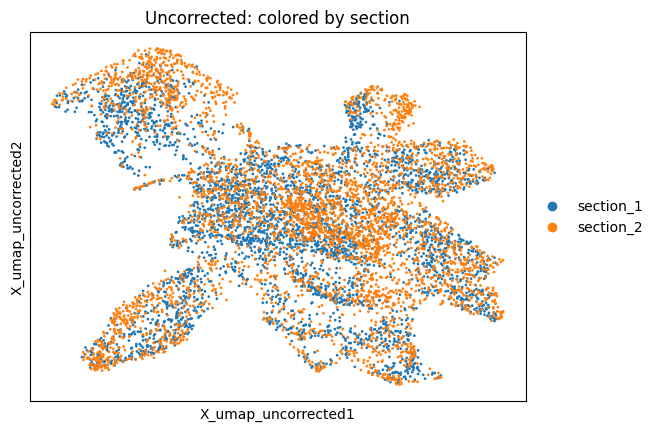

In [6]:
sc.pp.neighbors(adata_vis, use_rep="X_pca")
sc.tl.umap(adata_vis)
adata_vis.obsm["X_umap_uncorrected"] = adata_vis.obsm["X_umap"].copy()

sc.pl.embedding(adata_vis, basis="X_umap_uncorrected", color="batch", title="Uncorrected: colored by section")

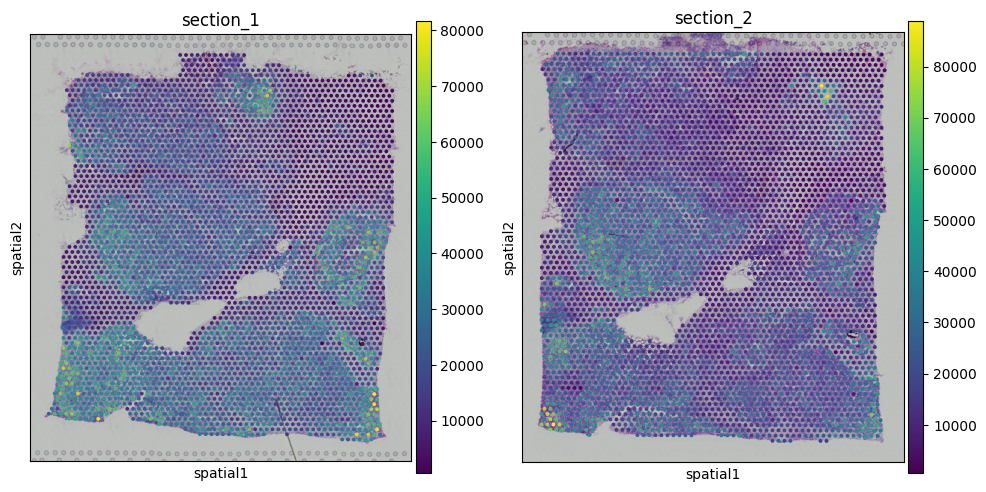

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(10, 5))
for ax, lib in zip(axes, ["section_1", "section_2"]):
    sc.pl.spatial(
        adata_vis[adata_vis.obs["batch"] == lib],
        color="total_counts",
        library_id=lib,
        ax=ax,
        show=False,
        title=lib,
    )
plt.tight_layout()

## 3.4 Batch correction with Harmony

2026-09-29 03:30:10,453 - harmonypy - INFO - Computing initial centroids with sklearn.KMeans...
INFO:harmonypy:Computing initial centroids with sklearn.KMeans...
2026-09-29 03:30:13,220 - harmonypy - INFO - sklearn.KMeans initialization complete.
INFO:harmonypy:sklearn.KMeans initialization complete.
2026-09-29 03:30:13,288 - harmonypy - INFO - Iteration 1 of 10
INFO:harmonypy:Iteration 1 of 10
2026-09-29 03:30:16,020 - harmonypy - INFO - Iteration 2 of 10
INFO:harmonypy:Iteration 2 of 10
2026-09-29 03:30:18,708 - harmonypy - INFO - Iteration 3 of 10
INFO:harmonypy:Iteration 3 of 10
2026-09-29 03:30:22,903 - harmonypy - INFO - Iteration 4 of 10
INFO:harmonypy:Iteration 4 of 10
2026-09-29 03:30:26,166 - harmonypy - INFO - Iteration 5 of 10
INFO:harmonypy:Iteration 5 of 10
2026-09-29 03:30:27,593 - harmonypy - INFO - Iteration 6 of 10
INFO:harmonypy:Iteration 6 of 10
2026-09-29 03:30:28,732 - harmonypy - INFO - Iteration 7 of 10
INFO:harmonypy:Iteration 7 of 10
2026-09-29 03:30:29,781 - 

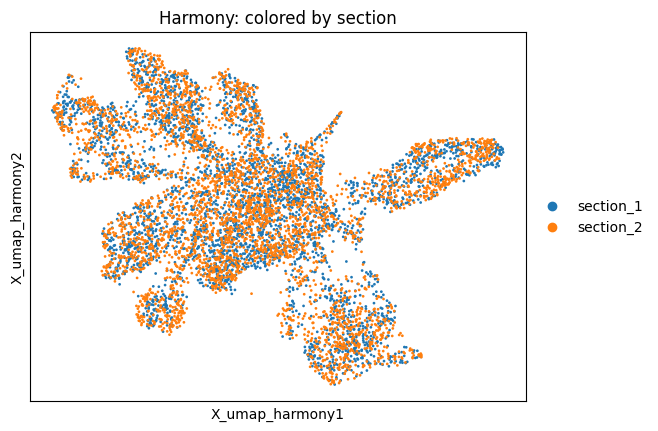

In [8]:
sc.external.pp.harmony_integrate(adata_vis, key="batch")

sc.pp.neighbors(adata_vis, use_rep="X_pca_harmony")
sc.tl.umap(adata_vis)
adata_vis.obsm["X_umap_harmony"] = adata_vis.obsm["X_umap"].copy()

sc.pl.embedding(adata_vis, basis="X_umap_harmony", color="batch", title="Harmony: colored by section")

## 3.5 Batch correction with Scanorama

Found 2000 genes among all datasets
[[0.       0.947604]
 [0.       0.      ]]
Processing datasets (0, 1)


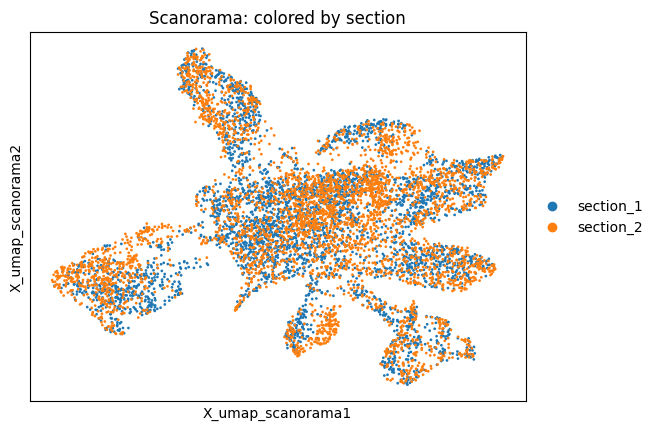

In [9]:
batch_cats_vis = adata_vis.obs["batch"].cat.categories
adata_list_vis = [adata_vis[adata_vis.obs["batch"] == b].copy() for b in batch_cats_vis]

scanorama.integrate_scanpy(adata_list_vis, dimred=30)

adata_vis.obsm["X_scanorama"] = np.zeros((adata_vis.n_obs, 30))
for b, ad_b in zip(batch_cats_vis, adata_list_vis):
    adata_vis.obsm["X_scanorama"][adata_vis.obs["batch"] == b] = ad_b.obsm["X_scanorama"]

sc.pp.neighbors(adata_vis, use_rep="X_scanorama")
sc.tl.umap(adata_vis)
adata_vis.obsm["X_umap_scanorama"] = adata_vis.obsm["X_umap"].copy()

sc.pl.embedding(adata_vis, basis="X_umap_scanorama", color="batch", title="Scanorama: colored by section")

## 3.6 Compare methods, and check agreement back in space

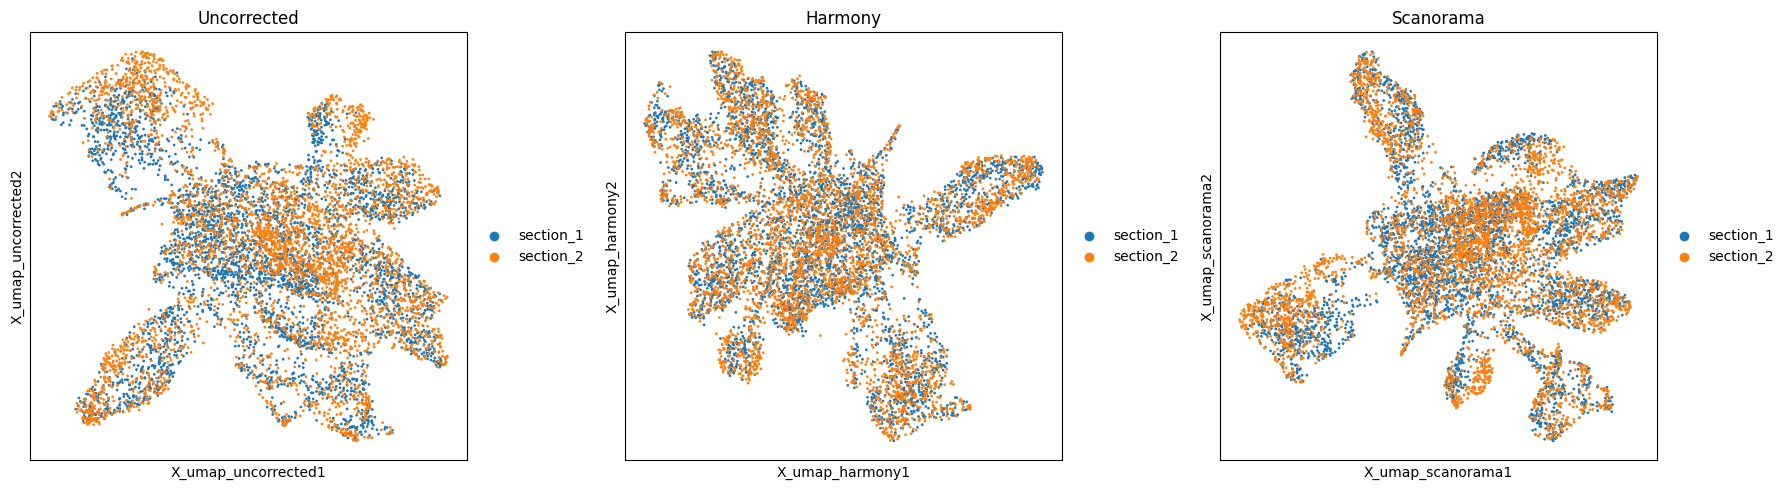

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, basis, title in zip(
    axes,
    ["X_umap_uncorrected", "X_umap_harmony", "X_umap_scanorama"],
    ["Uncorrected", "Harmony", "Scanorama"],
):
    sc.pl.embedding(adata_vis, basis=basis, color="batch", ax=ax, show=False, title=title)
plt.tight_layout()

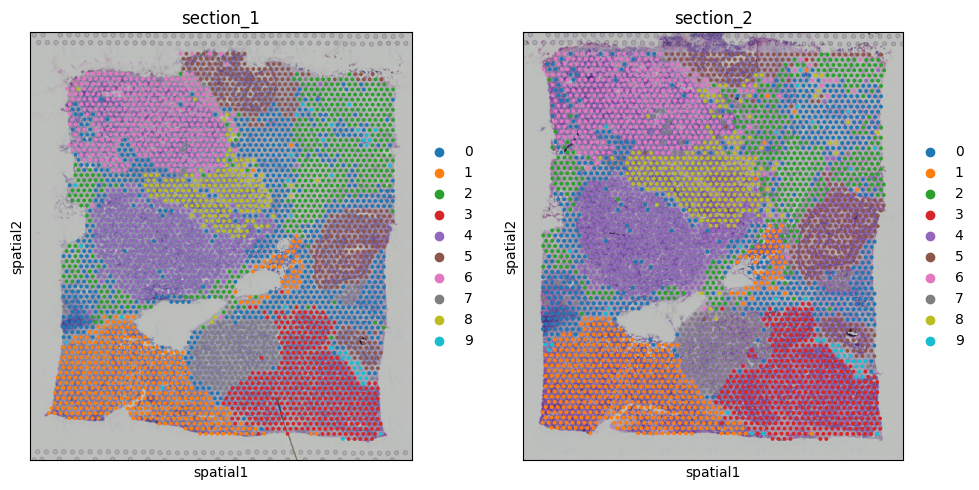

In [11]:
# Cluster the Harmony-corrected embedding and check that both sections agree on the same
# tissue regions once they are plotted back in physical space
sc.pp.neighbors(adata_vis, use_rep="X_pca_harmony")
sc.tl.leiden(adata_vis, key_added="leiden_harmony", flavor="igraph", n_iterations=-1, resolution=0.5)

fig, axes = plt.subplots(1, 2, figsize=(10, 5))
for ax, lib in zip(axes, ["section_1", "section_2"]):
    sc.pl.spatial(
        adata_vis[adata_vis.obs["batch"] == lib],
        color="leiden_harmony",
        library_id=lib,
        ax=ax,
        show=False,
        title=lib,
    )
plt.tight_layout()

# **4. Wrap-up**

Harmony is fast and works directly in PCA space, which makes it a good default; Scanorama's mutual-nearest-neighbor matching can be more robust when batches don't all share the same cell types or tissue regions. Both are complementary to graph-based methods like BBKNN and deep generative methods like scVI, which are not covered here but are worth exploring if you need to integrate many batches or batches with very different compositions.

For further reading: the [Scanpy integration tutorials](https://scanpy.readthedocs.io/en/stable/tutorials/basics/integrating-data-using-ingest.html), the [Harmony paper](https://www.nature.com/articles/s41592-019-0619-0), and the [Scanorama paper](https://www.nature.com/articles/s41587-019-0113-3).